# SGD-based `SVMRankRecommender` vs sklearn `LinearSVC`

This notebook compares the current federated-friendly `SVMRankRecommender` against sklearn's `LinearSVC` on small toy classification problems.

The point is not to prove solver equivalence. The point is to check whether the current SGD-based implementation is stable enough to learn a reasonable linear separator on common toy data.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate repo root from notebook path.")


repo_root = find_repo_root(Path.cwd().resolve())
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from fed_perso_xai.recommender.model import PairwiseLogisticConfig, SVMRankRecommender

## Helpers

In [2]:
def train_custom_svm(
    X_train: np.ndarray,
    y_train: np.ndarray,
    *,
    seed: int,
    epochs: int = 200,
    batch_size: int = 32,
    learning_rate: float = 0.05,
    svm_c: float = 1.0,
    svm_intercept_scaling: float = 1.0,
) -> SVMRankRecommender:
    model = SVMRankRecommender.from_config(
        n_features=X_train.shape[1],
        config=PairwiseLogisticConfig(
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
            svm_c=svm_c,
            svm_intercept_scaling=svm_intercept_scaling,
        ),
    )
    model.fit(X_train, y_train, seed=seed)
    return model


def predict_custom_labels(model: SVMRankRecommender, X: np.ndarray) -> np.ndarray:
    return model.predict_pairwise(X)


def make_dataset(*, n_samples: int = 400, cluster_std: float = 1.6, random_state: int = 7):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=[(-2.5, -2.0), (2.5, 2.0)],
        cluster_std=cluster_std,
        random_state=random_state,
    )
    return train_test_split(X, y, test_size=0.25, stratify=y, random_state=random_state)


def fit_both_models(X_train_raw, X_test_raw, y_train, y_test, *, custom_seed: int):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    custom = train_custom_svm(X_train, y_train, seed=custom_seed)
    sklearn_model = LinearSVC(C=1.0, dual=False, max_iter=5000, random_state=0)
    sklearn_model.fit(X_train, y_train)

    metrics = {
        "custom_train_acc": accuracy_score(y_train, predict_custom_labels(custom, X_train)),
        "custom_test_acc": accuracy_score(y_test, predict_custom_labels(custom, X_test)),
        "sklearn_train_acc": accuracy_score(y_train, sklearn_model.predict(X_train)),
        "sklearn_test_acc": accuracy_score(y_test, sklearn_model.predict(X_test)),
        "custom_loss": custom.loss(X_train, y_train),
    }
    return scaler, custom, sklearn_model, metrics


def plot_decision_regions(ax, model, scaler, X_raw, y, *, title: str, kind: str):
    x_min, x_max = X_raw[:, 0].min() - 1.0, X_raw[:, 0].max() + 1.0
    y_min, y_max = X_raw[:, 1].min() - 1.0, X_raw[:, 1].max() + 1.0
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )
    grid_raw = np.c_[xx.ravel(), yy.ravel()]
    grid = scaler.transform(grid_raw)
    if kind == "custom":
        zz = model.predict_pairwise_logits(grid)
    elif kind == "sklearn":
        zz = model.decision_function(grid)
    else:
        raise ValueError(f"Unsupported kind: {kind}")
    zz = zz.reshape(xx.shape)

    ax.contourf(xx, yy, zz > 0.0, alpha=0.18, levels=1, cmap="coolwarm")
    ax.contour(xx, yy, zz, levels=[0.0], colors="black", linewidths=1.5)
    ax.scatter(X_raw[:, 0], X_raw[:, 1], c=y, cmap="coolwarm", edgecolor="black", s=25)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

## One visual comparison on an easy toy problem

In [3]:
X_train_raw, X_test_raw, y_train, y_test = make_dataset(cluster_std=1.4, random_state=13)
X_all_raw = np.vstack([X_train_raw, X_test_raw])
y_all = np.concatenate([y_train, y_test])

scaler, custom_model, sklearn_model, metrics = fit_both_models(
    X_train_raw,
    X_test_raw,
    y_train,
    y_test,
    custom_seed=0,
)

pd.DataFrame([metrics])

,custom_train_acc,custom_test_acc,sklearn_train_acc,sklearn_test_acc,custom_loss
0,1.0,0.98,1.0,0.98,5.571343


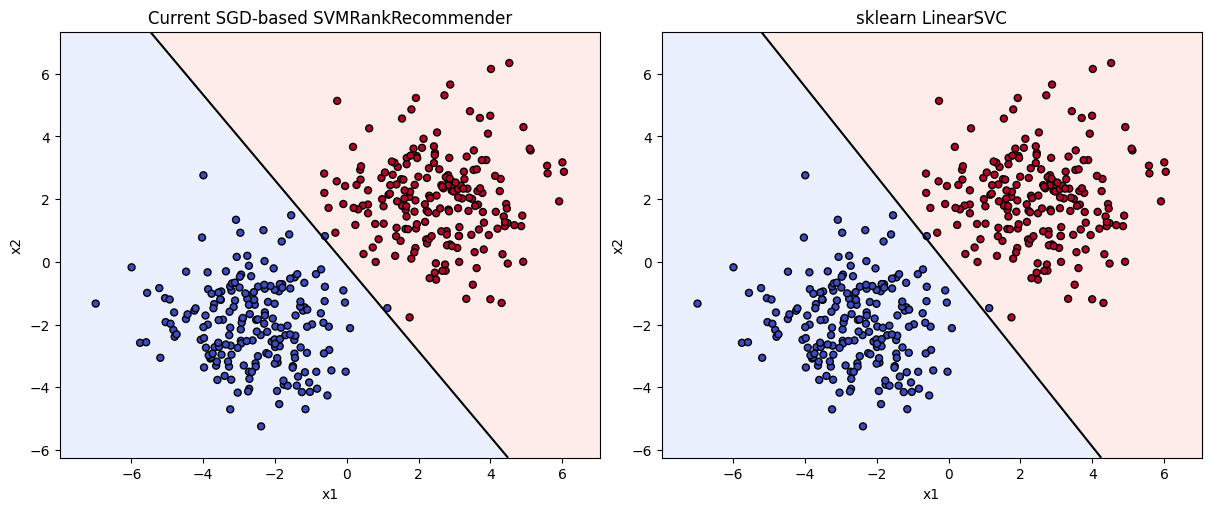

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

plot_decision_regions(
    axes[0],
    custom_model,
    scaler,
    X_all_raw,
    y_all,
    title="Current SGD-based SVMRankRecommender",
    kind="custom",
)
plot_decision_regions(
    axes[1],
    sklearn_model,
    scaler,
    X_all_raw,
    y_all,
    title="sklearn LinearSVC",
    kind="sklearn",
)

plt.show()

## Multi-seed stability check

The custom model depends on mini-batch order, so the seed matters. The sklearn `LinearSVC` baseline is included as a reference point.

In [5]:
def run_stability_experiment(cluster_std: float, dataset_seed: int) -> pd.DataFrame:
    X_train_raw, X_test_raw, y_train, y_test = make_dataset(
        cluster_std=cluster_std,
        random_state=dataset_seed,
    )
    rows = []
    for custom_seed in range(10):
        _, _, _, metrics = fit_both_models(
            X_train_raw,
            X_test_raw,
            y_train,
            y_test,
            custom_seed=custom_seed,
        )
        rows.append({"custom_seed": custom_seed, **metrics})
    return pd.DataFrame(rows)


easy_df = run_stability_experiment(cluster_std=1.4, dataset_seed=13)
hard_df = run_stability_experiment(cluster_std=2.3, dataset_seed=21)


In [6]:
summary = pd.concat(
    {
        "easy": easy_df.drop(columns=["custom_seed"]).agg(["mean", "std", "min", "max"]),
        "harder": hard_df.drop(columns=["custom_seed"]).agg(["mean", "std", "min", "max"]),
    },
    axis=0,
)
summary

custom_train_acc  custom_test_acc  sklearn_train_acc  \
easy   mean          1.000000     9.800000e-01       1.000000e+00   
       std           0.000000     1.170278e-16       0.000000e+00   
       min           1.000000     9.800000e-01       1.000000e+00   
       max           1.000000     9.800000e-01       1.000000e+00   
harder mean          0.920667     9.000000e-01       9.200000e-01   
       std           0.001405     0.000000e+00       1.170278e-16   
       min           0.920000     9.000000e-01       9.200000e-01   
       max           0.923333     9.000000e-01       9.200000e-01   

             sklearn_test_acc  custom_loss  
easy   mean      9.800000e-01     5.571112  
       std       1.170278e-16     0.002752  
       min       9.800000e-01     5.566064  
       max       9.800000e-01     5.576251  
harder mean      9.000000e-01    80.668995  
       std       0.000000e+00     0.026422  
       min       9.000000e-01    80.639297  
       max       9.000000e-01    80.735098

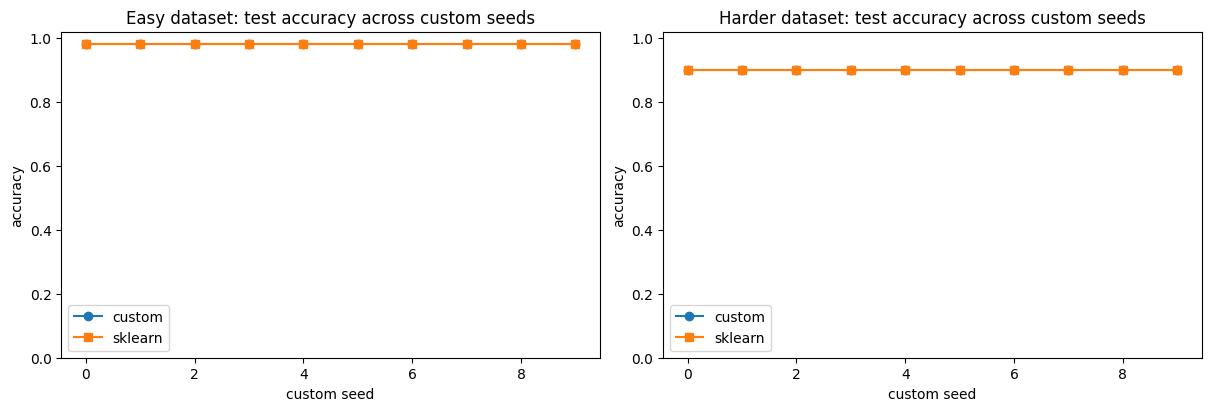

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(easy_df["custom_seed"], easy_df["custom_test_acc"], marker="o", label="custom")
axes[0].plot(easy_df["custom_seed"], easy_df["sklearn_test_acc"], marker="s", label="sklearn")
axes[0].set_title("Easy dataset: test accuracy across custom seeds")
axes[0].set_xlabel("custom seed")
axes[0].set_ylabel("accuracy")
axes[0].set_ylim(0.0, 1.02)
axes[0].legend()

axes[1].plot(hard_df["custom_seed"], hard_df["custom_test_acc"], marker="o", label="custom")
axes[1].plot(hard_df["custom_seed"], hard_df["sklearn_test_acc"], marker="s", label="sklearn")
axes[1].set_title("Harder dataset: test accuracy across custom seeds")
axes[1].set_xlabel("custom seed")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0.0, 1.02)
axes[1].legend()

plt.show()

## Reading the result

If the custom model stays close to sklearn on the easy case and does not collapse across seeds on the harder case, that is usually enough evidence that the SGD-based local solver is stable enough for basic linear classification.

If it shows large variance across seeds, the first parameters to revisit are:
- `learning_rate`
- `epochs`
- `batch_size`
- `svm_c`
- feature scaling